In [1]:
!pip -q install ucimlrepo wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from PIL import Image

from ucimlrepo import fetch_ucirepo
import wfdb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

pd.set_option("display.max_columns", None)
sns.set_context("notebook")
RANDOM_STATE = 42

print("Environment setup complete.")


Environment setup complete.


### Why a multimodal loader is needed
Healthcare datasets are heterogeneous. Tabular records may contain demographics and laboratory values, clinical notes contain unstructured text, medical images contain pixels and metadata, and physiological signals contain time-series samples. Each modality therefore requires a different loading and inspection strategy.


## 2. Tabular and Medical Data - UCI Cleveland Heart Disease

The Cleveland Heart Disease dataset is commonly used for cardiovascular classification.  
The original target, `num`, ranges from **0 to 4**:

- `0` = no heart disease
- `1-4` = presence of heart disease

For the baseline binary classifier, the target is converted to:

- `0` = No disease
- `1` = Disease present


In [3]:
heart = fetch_ucirepo(id=45)

X_raw = heart.data.features.copy()
y_raw = heart.data.targets.copy()

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

display(X_raw.head())
display(y_raw.head())


Feature shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


### 2.1 Inspect Schema, Data Types, and Missing Values

In [4]:
print("Feature columns:")
print(list(X_raw.columns))

print("\nData types:")
display(X_raw.dtypes.to_frame("dtype"))

print("\nMissing values before cleaning:")
display(X_raw.isna().sum().to_frame("missing_values"))

print("\nBasic feature summary:")
display(X_raw.describe(include="all").T)


Feature columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data types:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Missing values before cleaning:


,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Basic feature summary:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 2.2 Clean the Medical Dataset

In [5]:
X = X_raw.apply(pd.to_numeric, errors="coerce")

target_col = y_raw.columns[0]
y_numeric = pd.to_numeric(y_raw[target_col], errors="coerce")

y = (y_numeric > 0).astype(int)
y.name = "heart_disease"

heart_df = X.copy()
heart_df["heart_disease"] = y

print("Dataset shape before cleaning:", heart_df.shape)

heart_df = heart_df.dropna(subset=["heart_disease"]).reset_index(drop=True)

feature_cols = [c for c in heart_df.columns if c != "heart_disease"]
heart_df[feature_cols] = heart_df[feature_cols].apply(
    lambda col: col.fillna(col.median())
)

print("Missing values after cleaning:", heart_df.isna().sum().sum())
print("Final shape:", heart_df.shape)

display(heart_df.head())


Dataset shape before cleaning: (303, 14)
Missing values after cleaning: 0
Final shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### Cleaning note
The dataset is small, so deleting every row containing missing values could unnecessarily reduce the sample size. For this baseline experiment, missing numeric feature values are replaced with the **median of the corresponding feature**.


### 2.3 Demonstrate Tabular Data in Different Formats

In [6]:
sample_tabular = heart_df.head(20)

csv_path = "/content/heart_sample.csv"
xlsx_path = "/content/heart_sample.xlsx"
json_path = "/content/heart_sample.json"

sample_tabular.to_csv(csv_path, index=False)
sample_tabular.to_excel(xlsx_path, index=False)
sample_tabular.to_json(json_path, orient="records", indent=2)

csv_data = pd.read_csv(csv_path)
excel_data = pd.read_excel(xlsx_path)
json_data = pd.read_json(json_path)

print("CSV shape:", csv_data.shape)
print("Excel shape:", excel_data.shape)
print("JSON shape:", json_data.shape)

display(csv_data.head(3))


CSV shape: (20, 14)
Excel shape: (20, 14)
JSON shape: (20, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


This demonstrates that the same clinical tabular information can be ingested from **CSV, Excel, and JSON** using `pandas`.

### 2.4 Basic Exploratory Data Analysis

Class counts:


,count
heart_disease,
No disease,164
Disease,139


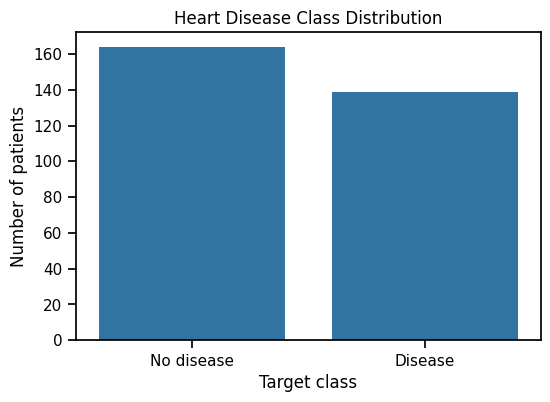

In [7]:
print("Class counts:")
display(
    heart_df["heart_disease"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No disease", 1: "Disease"})
    .to_frame("count")
)

plt.figure(figsize=(6, 4))
sns.countplot(data=heart_df, x="heart_disease")
plt.xticks([0, 1], ["No disease", "Disease"])
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target class")
plt.ylabel("Number of patients")
plt.show()


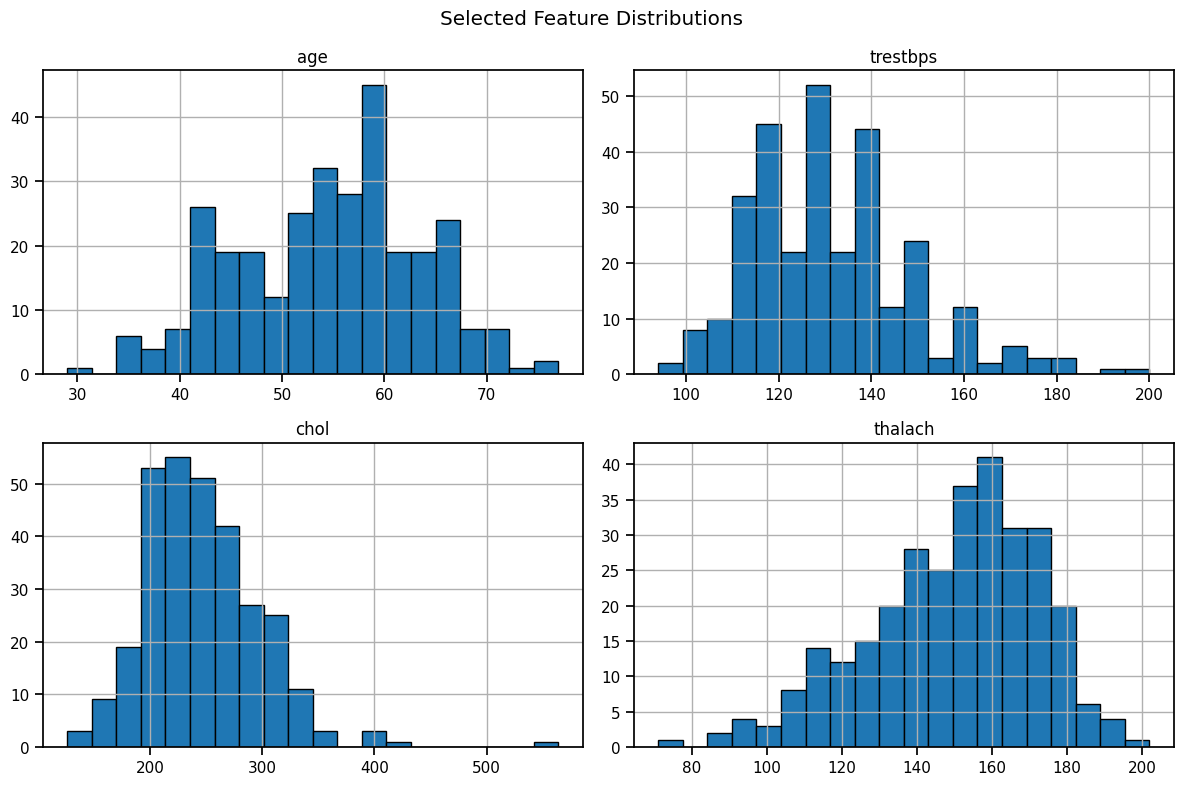

In [8]:
candidate_features = ["age", "trestbps", "chol", "thalach"]
plot_features = [c for c in candidate_features if c in heart_df.columns]

if plot_features:
    heart_df[plot_features].hist(figsize=(12, 8), bins=20, edgecolor="black")
    plt.suptitle("Selected Feature Distributions")
    plt.tight_layout()
    plt.show()
else:
    print("Expected feature names were not found. Available columns:")
    print(list(heart_df.columns))


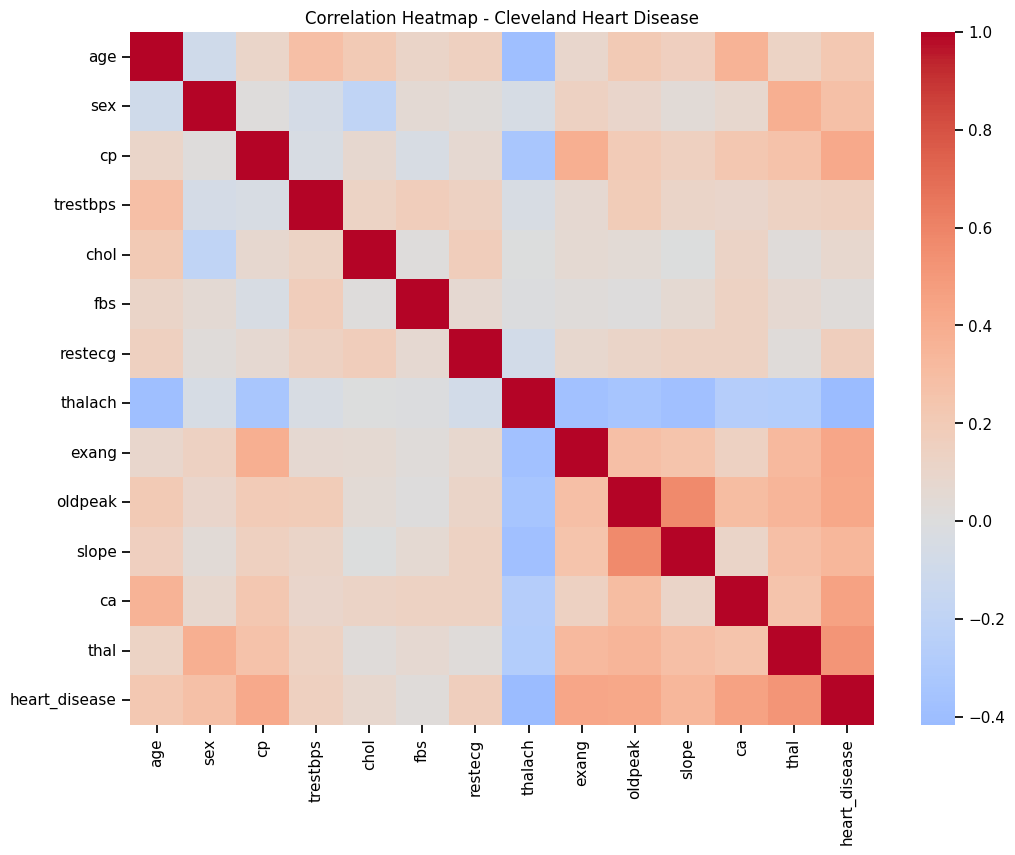

In [9]:
plt.figure(figsize=(12, 9))
corr = heart_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Cleveland Heart Disease")
plt.show()


### 2.5 Baseline Logistic Regression Classifier

In [10]:
X_model = heart_df.drop(columns="heart_disease")
y_model = heart_df["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_model
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))


Accuracy: 0.8689
ROC-AUC:  0.9513

Classification Report:
              precision    recall  f1-score   support

  No disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



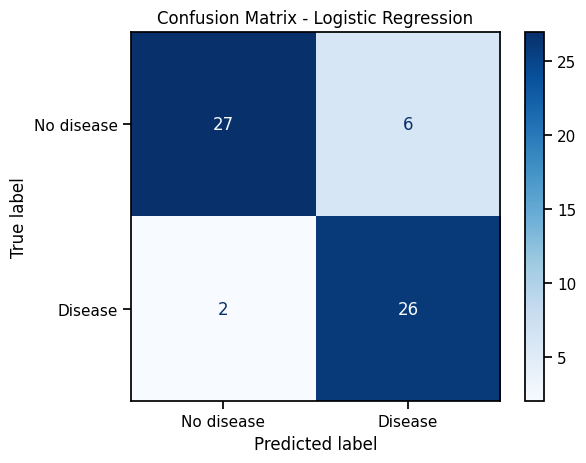

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No disease", "Disease"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


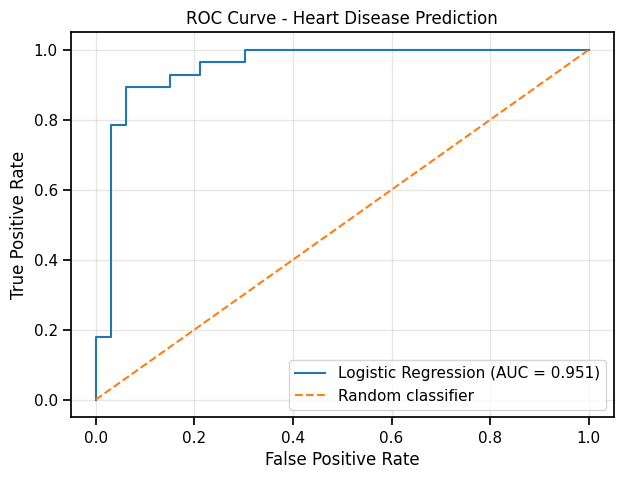

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Interpretation
The classifier is included as a **baseline demonstration**, not as a clinical decision system. Accuracy measures overall correctness, while ROC-AUC summarizes how well the model separates patients with and without disease across decision thresholds. In healthcare, errors should also be evaluated according to their clinical consequences.


## 3. Textual Data - Clinical Note Demonstration

A synthetic clinical note is used so that no real patient-identifying information is present. The experiment demonstrates:

- creating and reading a `.txt` clinical note,
- reading structured text from JSON,
- text cleaning,
- tokenization,
- stop-word removal,
- word-frequency analysis,
- simple keyword extraction.


In [13]:
clinical_note = """Patient presents with intermittent chest pain during exertion for the past two weeks.
Pain is described as pressure-like and occasionally radiates to the left arm.
The patient reports shortness of breath and fatigue while climbing stairs.
No fever or recent respiratory infection is reported.
Past history includes hypertension and elevated cholesterol.
Further cardiovascular evaluation, ECG, and laboratory investigations are advised."""

txt_path = "/content/clinical_note.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write(clinical_note)

with open(txt_path, "r", encoding="utf-8") as f:
    loaded_note = f.read()

print(loaded_note)


Patient presents with intermittent chest pain during exertion for the past two weeks.
Pain is described as pressure-like and occasionally radiates to the left arm.
The patient reports shortness of breath and fatigue while climbing stairs.
No fever or recent respiratory infection is reported.
Past history includes hypertension and elevated cholesterol.
Further cardiovascular evaluation, ECG, and laboratory investigations are advised.


In [14]:
clinical_json = {
    "patient_id": "SYNTHETIC_001",
    "note_date": "2026-09-11",
    "note_type": "synthetic_demo",
    "text": clinical_note
}

json_note_path = "/content/clinical_note.json"

with open(json_note_path, "w", encoding="utf-8") as f:
    json.dump(clinical_json, f, indent=2)

with open(json_note_path, "r", encoding="utf-8") as f:
    loaded_json_note = json.load(f)

display(loaded_json_note)


{'patient_id': 'SYNTHETIC_001',
 'note_date': '2026-09-11',
 'note_type': 'synthetic_demo',
 'text': 'Patient presents with intermittent chest pain during exertion for the past two weeks.\nPain is described as pressure-like and occasionally radiates to the left arm.\nThe patient reports shortness of breath and fatigue while climbing stairs.\nNo fever or recent respiratory infection is reported.\nPast history includes hypertension and elevated cholesterol.\nFurther cardiovascular evaluation, ECG, and laboratory investigations are advised.'}

### 3.1 Clean and Tokenize the Note

In [15]:
tokens = re.findall(r"[A-Za-z]+", loaded_note.lower())

simple_stopwords = {
    "the", "a", "an", "and", "or", "is", "are", "was", "were",
    "to", "of", "for", "with", "in", "on", "as", "at", "this",
    "that", "it", "be", "been", "while", "during", "past", "no"
}

clean_tokens = [word for word in tokens if word not in simple_stopwords]

print("Original token count:", len(tokens))
print("Token count after stop-word removal:", len(clean_tokens))
print("\nFirst 30 cleaned tokens:")
print(clean_tokens[:30])


Original token count: 61
Token count after stop-word removal: 40

First 30 cleaned tokens:
['patient', 'presents', 'intermittent', 'chest', 'pain', 'exertion', 'two', 'weeks', 'pain', 'described', 'pressure', 'like', 'occasionally', 'radiates', 'left', 'arm', 'patient', 'reports', 'shortness', 'breath', 'fatigue', 'climbing', 'stairs', 'fever', 'recent', 'respiratory', 'infection', 'reported', 'history', 'includes']


### 3.2 Word Frequency and Key Terms

,word,frequency
0,patient,2
1,pain,2
2,presents,1
3,intermittent,1
4,chest,1
5,exertion,1
6,two,1
7,weeks,1
8,described,1
9,pressure,1


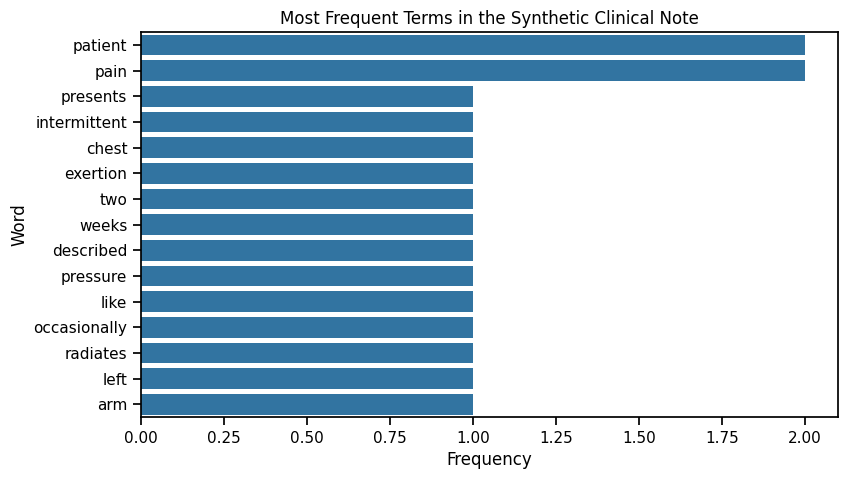

In [16]:
word_freq = Counter(clean_tokens)
top_words = word_freq.most_common(15)

freq_df = pd.DataFrame(top_words, columns=["word", "frequency"])
display(freq_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=freq_df, x="frequency", y="word")
plt.title("Most Frequent Terms in the Synthetic Clinical Note")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


In [17]:
medical_keywords = {
    "chest", "pain", "pressure", "arm", "shortness", "breath",
    "fatigue", "hypertension", "cholesterol", "cardiovascular", "ecg"
}

detected_keywords = sorted(set(clean_tokens).intersection(medical_keywords))

print("Detected medical keywords:")
print(detected_keywords)


Detected medical keywords:
['arm', 'breath', 'cardiovascular', 'chest', 'cholesterol', 'ecg', 'fatigue', 'hypertension', 'pain', 'pressure', 'shortness']


### Text interpretation
Unstructured clinical notes can add symptom and history information that may not appear in structured tables. In a real medical NLP pipeline, stronger de-identification, clinical tokenization, negation detection, and domain-specific embeddings would be required.


## 4. Image Data - PNG, JPEG, and TIFF

This section creates a **synthetic grayscale medical-style image** only for demonstrating image I/O. It is not a real scan and must not be interpreted diagnostically.

The image is saved and reloaded as:
- PNG
- JPEG
- TIFF


In [18]:
size = 256
y_grid, x_grid = np.mgrid[0:size, 0:size]

center_x, center_y = size / 2, size / 2
distance = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)

image_array = 230 - np.clip(distance * 1.2, 0, 170)

ellipse = (((x_grid - 150) / 35)**2 + ((y_grid - 120) / 22)**2) <= 1
image_array[ellipse] -= 60

image_array = np.clip(image_array, 0, 255).astype(np.uint8)

synthetic_image = Image.fromarray(image_array)

png_path = "/content/synthetic_medical_image.png"
jpg_path = "/content/synthetic_medical_image.jpg"
tiff_path = "/content/synthetic_medical_image.tiff"

synthetic_image.save(png_path)
synthetic_image.save(jpg_path, quality=95)
synthetic_image.save(tiff_path)

print("Synthetic image files created.")


Synthetic image files created.


### 4.1 Read and Inspect Different Image Formats

In [19]:
image_paths = [png_path, jpg_path, tiff_path]

for path in image_paths:
    with Image.open(path) as img:
        print(
            f"{os.path.basename(path):35s} "
            f"Format={img.format:5s} Size={img.size} Mode={img.mode}"
        )


synthetic_medical_image.png         Format=PNG   Size=(256, 256) Mode=L
synthetic_medical_image.jpg         Format=JPEG  Size=(256, 256) Mode=L
synthetic_medical_image.tiff        Format=TIFF  Size=(256, 256) Mode=L


### 4.2 Display and Resize the Image

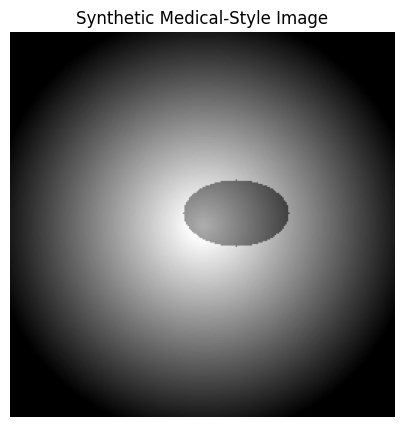

Original size: (256, 256)
Resized size: (128, 128)


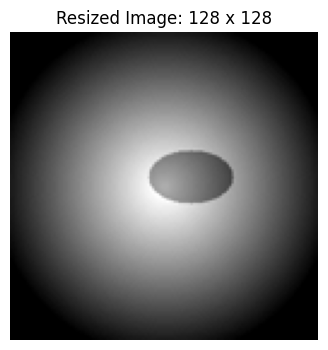

In [20]:
with Image.open(png_path) as img:
    loaded_image = img.copy()

plt.figure(figsize=(5, 5))
plt.imshow(loaded_image, cmap="gray")
plt.title("Synthetic Medical-Style Image")
plt.axis("off")
plt.show()

resized_image = loaded_image.resize((128, 128))

print("Original size:", loaded_image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(4, 4))
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Image: 128 x 128")
plt.axis("off")
plt.show()


### 4.3 Normalize Pixel Values

In [21]:
pixel_array = np.asarray(resized_image).astype(np.float32)
normalized_pixels = pixel_array / 255.0

print("Original pixel range:", pixel_array.min(), "to", pixel_array.max())
print("Normalized pixel range:", normalized_pixels.min(), "to", normalized_pixels.max())
print("Tensor-like array shape:", normalized_pixels.shape)


Original pixel range: 60.0 to 219.0
Normalized pixel range: 0.23529412 to 0.85882354
Tensor-like array shape: (128, 128)


### Image interpretation
Medical imaging pipelines commonly standardize image size and pixel intensity before modeling. Real DICOM/NIfTI workflows also need modality-specific metadata handling, anonymization, orientation handling, and sometimes windowing.


## 5. Signal Data - MIT-BIH ECG

The MIT-BIH Arrhythmia Database stores ECG records using WFDB-compatible files.  
For record `100`, the important files are:

- `100.hea` - header/metadata
- `100.dat` - signal samples
- `100.atr` - expert annotations

This section downloads an initial segment of record `100` through the `wfdb` Python library.


In [22]:
record_name = "100"
seconds_to_load = 10
expected_fs = 360
samples_to_load = seconds_to_load * expected_fs

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb",
    sampfrom=0,
    sampto=samples_to_load
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb",
    sampfrom=0,
    sampto=samples_to_load
)

print("Sampling frequency:", record.fs, "Hz")
print("Number of signal channels:", record.n_sig)
print("Signal names:", record.sig_name)
print("Signal array shape:", record.p_signal.shape)
print("Number of annotations in segment:", len(annotation.sample))


Sampling frequency: 360 Hz
Number of signal channels: 2
Signal names: ['MLII', 'V5']
Signal array shape: (3600, 2)
Number of annotations in segment: 14


### 5.1 Plot ECG Signal with Beat Annotations

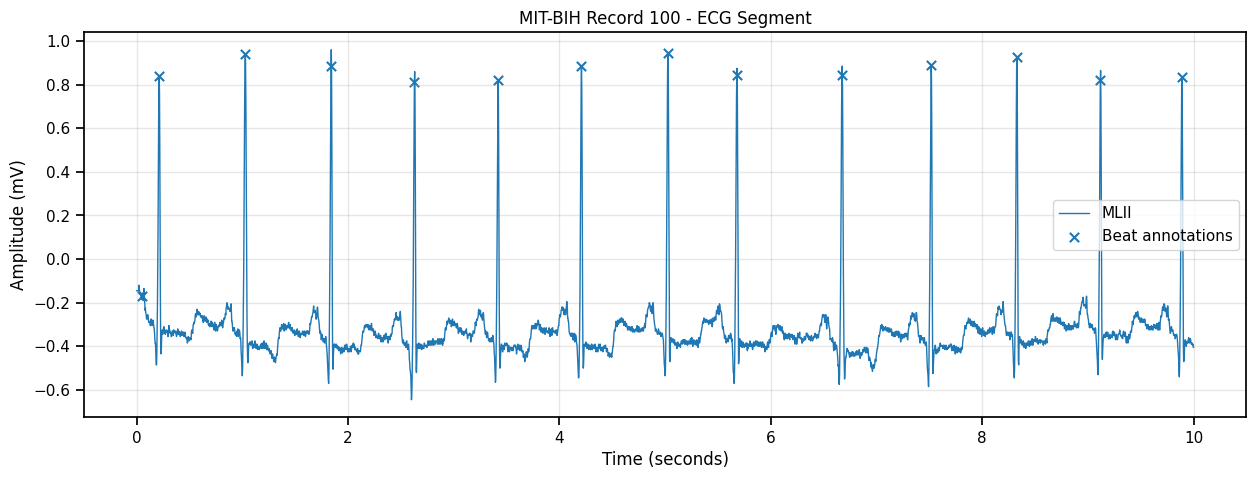

In [23]:
fs = record.fs
signal = record.p_signal[:, 0]
time = np.arange(len(signal)) / fs

plt.figure(figsize=(15, 5))
plt.plot(time, signal, linewidth=1, label=record.sig_name[0])

ann_samples = annotation.sample
valid_ann = ann_samples[ann_samples < len(signal)]

plt.scatter(
    valid_ann / fs,
    signal[valid_ann],
    marker="x",
    s=45,
    label="Beat annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.title("MIT-BIH Record 100 - ECG Segment")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 5.2 Inspect Annotation Symbols

In [24]:
annotation_table = pd.DataFrame({
    "sample": annotation.sample,
    "time_seconds": annotation.sample / fs,
    "symbol": annotation.symbol
})

display(annotation_table.head(20))

print("Annotation symbol counts:")
display(annotation_table["symbol"].value_counts().to_frame("count"))


,sample,time_seconds,symbol
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


Annotation symbol counts:


,count
symbol,
N,12
+,1
A,1


### 5.3 Compute Basic RR-Interval / Heart-Rate Statistics

In [25]:
beat_symbols = {
    "N", "L", "R", "B", "A", "a", "J", "S",
    "V", "r", "F", "e", "j", "n", "E", "/", "f", "Q"
}

beat_samples = np.array([
    sample
    for sample, symbol in zip(annotation.sample, annotation.symbol)
    if symbol in beat_symbols
])

rr_intervals = np.diff(beat_samples) / fs
rr_intervals = rr_intervals[(rr_intervals >= 0.30) & (rr_intervals <= 2.00)]

if len(rr_intervals) > 0:
    instantaneous_hr = 60 / rr_intervals

    print(f"Number of usable RR intervals: {len(rr_intervals)}")
    print(f"Mean RR interval: {np.mean(rr_intervals):.3f} s")
    if len(rr_intervals) > 1:
        print(f"SDNN (std of RR): {np.std(rr_intervals, ddof=1):.3f} s")
    print(f"Mean heart rate: {np.mean(instantaneous_hr):.2f} bpm")
    print(f"Min heart rate:  {np.min(instantaneous_hr):.2f} bpm")
    print(f"Max heart rate:  {np.max(instantaneous_hr):.2f} bpm")
else:
    print("Not enough usable beat annotations in this short segment.")


Number of usable RR intervals: 12
Mean RR interval: 0.806 s
SDNN (std of RR): 0.076 s
Mean heart rate: 75.01 bpm
Min heart rate:  60.34 bpm
Max heart rate:  91.91 bpm


### Signal interpretation
Physiological signals differ from ordinary tabular data because their **sampling rate and time order must be preserved**. ECG analysis frequently requires filtering, beat detection/annotation alignment, segmentation, and calculation of interval-based features.


### 5.4 Optional: Basic ECG Filtering Demonstration

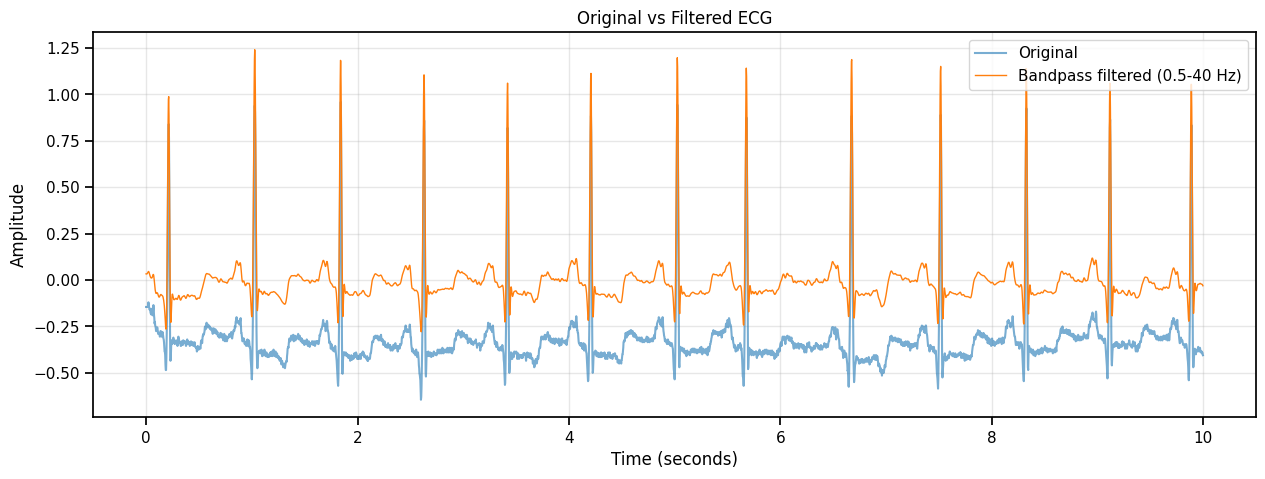

In [26]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

filtered_signal = bandpass_filter(signal, fs)

plt.figure(figsize=(15, 5))
plt.plot(time, signal, alpha=0.6, label="Original")
plt.plot(time, filtered_signal, linewidth=1, label="Bandpass filtered (0.5-40 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Original vs Filtered ECG")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Simple Modular Loader Demonstration

A robust multimodal ingestion system should detect a file type and dispatch it to an appropriate loader. The following simplified function demonstrates the idea for local tabular, textual, and image files.


In [27]:
def load_multimodal_file(path):
    extension = os.path.splitext(path)[1].lower()

    if extension == ".csv":
        data = pd.read_csv(path)
        return {"modality": "tabular", "format": "CSV", "data": data}

    if extension in {".xls", ".xlsx"}:
        data = pd.read_excel(path)
        return {"modality": "tabular", "format": "Excel", "data": data}

    if extension == ".json":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return {"modality": "structured/text", "format": "JSON", "data": data}

    if extension == ".txt":
        with open(path, "r", encoding="utf-8") as f:
            data = f.read()
        return {"modality": "text", "format": "TXT", "data": data}

    if extension in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
        image = Image.open(path)
        return {
            "modality": "image",
            "format": image.format,
            "size": image.size,
            "mode": image.mode,
            "data": image.copy()
        }

    raise ValueError(f"Unsupported file type: {extension}")


In [28]:
test_files = [
    csv_path,
    xlsx_path,
    txt_path,
    json_note_path,
    png_path,
    tiff_path
]

for file_path in test_files:
    result = load_multimodal_file(file_path)
    print(
        os.path.basename(file_path),
        "->",
        result["modality"],
        "/",
        result["format"]
    )


heart_sample.csv -> tabular / CSV
heart_sample.xlsx -> tabular / Excel
clinical_note.txt -> text / TXT
clinical_note.json -> structured/text / JSON
synthetic_medical_image.png -> image / PNG
synthetic_medical_image.tiff -> image / TIFF


## 7. Validator / Inspector Concept

In [29]:
def inspect_loaded_object(obj, name="object"):
    print(f"--- {name} ---")

    if isinstance(obj, pd.DataFrame):
        print("Type: pandas DataFrame")
        print("Shape:", obj.shape)
        print("Missing values:", int(obj.isna().sum().sum()))
        display(obj.head())

    elif isinstance(obj, str):
        print("Type: text")
        print("Characters:", len(obj))
        print("Words:", len(obj.split()))
        print("Preview:", obj[:250])

    elif isinstance(obj, Image.Image):
        print("Type: PIL Image")
        print("Size:", obj.size)
        print("Mode:", obj.mode)

    elif isinstance(obj, np.ndarray):
        print("Type: NumPy array")
        print("Shape:", obj.shape)
        print("Min:", np.min(obj))
        print("Max:", np.max(obj))
        print("Mean:", np.mean(obj))

    else:
        print("Type:", type(obj))

inspect_loaded_object(heart_df, "Heart Disease Table")
inspect_loaded_object(loaded_note, "Clinical Note")
inspect_loaded_object(loaded_image, "Synthetic Image")
inspect_loaded_object(signal, "ECG Signal")


--- Heart Disease Table ---
Type: pandas DataFrame
Shape: (303, 14)
Missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,heart_disease
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


--- Clinical Note ---
Type: text
Characters: 436
Words: 60
Preview: Patient presents with intermittent chest pain during exertion for the past two weeks.
Pain is described as pressure-like and occasionally radiates to the left arm.
The patient reports shortness of breath and fatigue while climbing stairs.
No fever or
--- Synthetic Image ---
Type: PIL Image
Size: (256, 256)
Mode: L
--- ECG Signal ---
Type: NumPy array
Shape: (3600,)
Min: -0.645
Max: 0.96
Mean: -0.31992222222222216


## 8. Multimodal Integration Discussion

### How the modalities could be combined

A future cardiovascular AI system could combine these modalities at the **patient level**:

| Modality | Example information | Potential contribution |
|---|---|---|
| Tabular | Age, cholesterol, blood pressure, maximum heart rate | Structured cardiovascular risk factors |
| ECG signal | Rhythm, RR intervals, waveform characteristics | Electrical and rhythm abnormalities |
| Clinical text | Chest pain, breathlessness, medical history | Symptoms and contextual information |
| Medical image | Cardiac or chest imaging features | Anatomical/structural information |

### Possible fusion pipeline

1. Assign every record a **de-identified patient ID**.
2. Align data using patient ID and timestamps.
3. Convert each modality into numerical features:
   - tabular values -> standardized numerical vector,
   - ECG -> rhythm/interval or learned signal features,
   - text -> clinical NLP embeddings/features,
   - images -> CNN/image embeddings.
4. Concatenate or otherwise fuse these representations.
5. Train a multimodal prediction model.
6. Validate the model using patient-level splits to prevent data leakage.

### Important healthcare considerations

- **Privacy:** Direct identifiers and protected health information must be removed.
- **Time alignment:** Data collected at different clinical times should not be mixed incorrectly.
- **Missing modalities:** Not every patient will have all tests.
- **Data leakage:** The same patient's information must not appear in both training and testing sets.
- **Clinical validation:** Good technical metrics alone do not prove clinical usefulness.


## 9. Result Summary

The experiment successfully demonstrates a modular approach for reading and processing multiple healthcare data modalities:

- **Tabular/medical:** UCI Cleveland Heart Disease data is loaded, inspected, cleaned, visualized, saved/read in multiple file formats, and used for a baseline Logistic Regression classifier.
- **Text:** A synthetic clinical note is read from TXT and JSON, cleaned, tokenized, and analyzed using term frequencies and keyword extraction.
- **Image:** A synthetic image is stored and read as PNG, JPEG, and TIFF, then resized and normalized.
- **Signal:** An MIT-BIH ECG segment is loaded through WFDB along with annotations, visualized, filtered, and used to compute basic RR/heart-rate statistics.
- **Integration:** A patient-level multimodal fusion strategy is outlined along with privacy, missingness, timing, and leakage concerns.


## 10. Conclusion

Healthcare AI requires more than loading a single spreadsheet. Different modalities have different structures, metadata, preprocessing requirements, and privacy risks. This experiment shows how Python can provide a common workflow while still using modality-specific readers and preprocessing.

A modular architecture with separate loaders, validation/inspection, preprocessing, metadata tracking, and patient-level alignment provides a practical foundation for larger multimodal healthcare AI systems.
